# Анализ CP 1

## Источник данных
`data/processed/vacancies.parquet` — готовый датасет для дальнейшей обработки, полученный скриптом `preprocessing_data.py`.
**Его можно загрузить по ссылке: https://drive.google.com/file/d/1DSojrM7FSwJPQWjMa93KFg2Necy89-CK/view?usp=sharing**

Скрипт уже сделал фильтрацию по `is_open` / наличию `name` и `salary`, опционально — по источнику и стране, парсинг HTML, навыков, языков, JSON-полей `requirements` / `benefits`, обрезку выбросов по зарплате (`10 000 ≤ salary_rub ≤ 5 000 000`), удалил дубликаты по `(id, data_source)`

Поэтому в этом ноутбуке не дублируется очистка — только анализ:
1. Описание датасета (объём, типы, колонки)
2. Sanity-check: остаточные пропуски, дубликаты, выбросы — чтобы убедиться, что предобработка отработала
3. Анализ таргета `salary_rub`
4. Анализ признаков (числовых, категориальных, булевых, временных)
5. Корректный train / val / test split + защита от data leakage
6. Обоснование метрики качества

### Задача
Hегрессия — предсказать `salary_rub` по описанию вакансии, навыкам, региону и др. признакам  
### Целевая метрика
MAE (основная), RMSE / R² / MedAE (вспомогательные)

## 0. Запуск очистки нового датасета
Для этого нужно найти или собрать собственный датасет, который хотите обработать. Положить его в `data/raw/vacancies.csv` и запустить preprocessing_data.py. Если файл уже обработан, то код его найдёт и выведет путь.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORT_IMG = PROJECT_ROOT / "report" / "images"
REPORT_IMG.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_PROCESSED / "vacancies.parquet"
assert DATA_PATH.exists(), f"Не найден файл {DATA_PATH} Сначала запустить preprocessing_data.py"
print(f"{DATA_PATH} ({DATA_PATH.stat().st_size / 1024**2:.1f} MB)")

/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/data/processed/vacancies.parquet (42.2 MB)


## 1. Загрузка и общее описание

In [2]:
df = pd.read_parquet(DATA_PATH)
print(f"Размер датасета: {df.shape[0]:,} строк × {df.shape[1]} столбцов")
df.head()

Размер датасета: 39,488 строк × 41 столбцов


,data_source,id,link,last_found_at,is_open,name,description,salary_from,salary_to,salary,experience,employer_id,employer_name,employer_type,employer_industry_id,employer_industry_name,accept_kids,accept_handicapped,accomodation,schedule,employment,country_id,country_name,region_id,region_name,region_district_id,region_district_name,role_id,role_name,description_length,skills,skills_count,languages_parsed,languages_count,has_test,is_premium,year,month,salary_rub,has_salary_from,has_salary_to
0,hh,79789667,https://hh.ru/vacancy/79789667,2023-11-01,True,Консультант в Тинькофф Банк (удалённо),Обязанности: Тинькофф – первый онлайн банк в Р...,38000,0,38000,0,78638,Тинькофф,company,0,None,False,False,None,remote,part,113,Россия,598,Челябинская область,5,Уральский,83,"Оператор call-центра, специалист контактного ц...",2705,[],0,[],0,False,False,2023,11,38000.0,True,False
1,hh,79812238,https://hh.ru/vacancy/79812238,2023-11-01,True,Инженер-технолог (беспилотие),АО «Научно-производственное предприятие «Радар...,70000,0,70000,3-6,167893,Радар ММС,company,0,None,False,False,None,full_day,full,113,Россия,475,Санкт-Петербург,2,Северо-Западный,40,Другое,1339,[],0,[],0,False,False,2023,11,70000.0,True,False
2,hh,83549154,https://hh.ru/vacancy/83549154,2023-11-01,True,Повар-универсал,"Универсамы ""Бегемаг"" - это современная, стабил...",40000,45000,45000,1-3,5829213,Наша Кухня Универсамы Бегемаг (Комбинат Питания),company,0,None,False,False,None,shift,full,113,Россия,263,Кемеровская область,6,Сибирский,94,"Повар, пекарь, кондитер",1032,[],0,[],0,False,False,2023,11,45000.0,True,True
3,hh,83549271,https://hh.ru/vacancy/83549271,2023-11-01,True,Продавец (Чебоксары),Сеть магазинов одежды CLEVER приглашает на раб...,0,40000,40000,0,923386,Клевер Восток,company,0,None,False,False,None,flexible,full,113,Россия,613,Чувашская Республика,4,Приволжский,97,"Продавец-консультант, продавец-кассир",783,[],0,[],0,False,False,2023,11,40000.0,False,True
4,hh,83539369,https://hh.ru/vacancy/83539369,2023-11-01,True,Консультант Тинькофф Бизнес (удалённо),Тинькофф Бизнес на связи с клиентами 24/7 по т...,41500,0,41500,0,78638,Тинькофф,company,0,None,False,True,None,remote,full,113,Россия,227,Калининградская область,2,Северо-Западный,83,"Оператор call-центра, специалист контактного ц...",2870,[],0,[],0,False,False,2023,11,41500.0,True,False


In [3]:
print("Колонки и их типы")
for c in df.columns:
    print(f"  - {c}: {df[c].dtype}")

Колонки и их типы
  - data_source: object
  - id: object
  - link: object
  - last_found_at: datetime64[ns]
  - is_open: bool
  - name: object
  - description: object
  - salary_from: int64
  - salary_to: int64
  - salary: int64
  - experience: object
  - employer_id: object
  - employer_name: object
  - employer_type: object
  - employer_industry_id: int64
  - employer_industry_name: object
  - accept_kids: bool
  - accept_handicapped: bool
  - accomodation: object
  - schedule: object
  - employment: object
  - country_id: int64
  - country_name: object
  - region_id: int64
  - region_name: object
  - region_district_id: int64
  - region_district_name: object
  - role_id: int64
  - role_name: object
  - description_length: int64
  - skills: object
  - skills_count: int64
  - languages_parsed: object
  - languages_count: int64
  - has_test: bool
  - is_premium: bool
  - year: int32
  - month: int32
  - salary_rub: float64
  - has_salary_from: bool
  - has_salary_to: bool


In [4]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
salary_from,39488.0,60575.266056,43311.560077,0.0,35000.0,50000.0,78000.0,1000000.0
salary_to,39488.0,49346.479234,68925.158354,0.0,0.0,35000.0,75000.0,3000000.0
salary,39488.0,79994.861983,60886.776559,10000.0,45000.0,60000.0,100000.0,3000000.0
employer_industry_id,39488.0,4.497341,10.658502,0.0,0.0,0.0,0.0,34.0
country_id,39488.0,113.000000,0.000000,113.0,113.0,113.0,113.0,113.0
region_id,39488.0,377.571515,130.209542,28.0,347.0,366.0,475.0,665.0
region_district_id,39488.0,3.172711,2.022264,1.0,1.0,3.0,5.0,8.0
role_id,39488.0,73.009243,39.354164,1.0,40.0,70.0,97.0,174.0
description_length,39488.0,1217.084557,715.716501,119.0,705.0,1087.0,1568.0,8987.0
skills_count,39488.0,3.028616,4.210596,0.0,0.0,1.0,5.0,30.0


In [ ]:
# df.describe(include=["object", "bool"]).T

### Объём
В датасете 39,488 строк и 40 колонок
### Источник
HH.ru (поле `data_source == 'hh'`), полученные скриптом предобработки из CSV-выгрузки, потому что сервис API рассматривает заявку на проект слишком долго... :(

## 2. Sanity-check после предобработки
Не пересоздаём очистку — просто убеждаемся, что предобработка отработала корректно.

In [5]:
TARGET = "salary_rub"

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing": missing, "pct": missing_pct})
missing_table

,missing,pct
accomodation,39488,100.00
employer_industry_name,32599,82.55
employer_type,28,0.07
employer_id,26,0.07


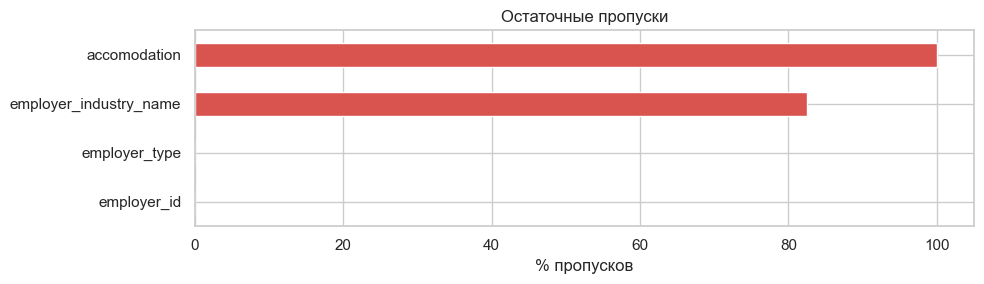

In [6]:
if not missing_table.empty:
    fig, ax = plt.subplots(figsize=(10, max(3, len(missing_table) * 0.3)))
    missing_table["pct"].plot.barh(ax=ax, color="#d9534f")
    ax.set_xlabel("% пропусков")
    ax.set_title("Остаточные пропуски")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(REPORT_IMG / "missing_values.png", dpi=120)
    plt.show()

In [7]:
hidden = {}
if "description" in df.columns:
    hidden["description пустое"] = df["description"].fillna("").str.strip().eq("").sum()
if "name" in df.columns:
    hidden["name пустое"] = df["name"].fillna("").str.strip().eq("").sum()
if "languages_parsed" in df.columns:
    hidden["languages_parsed пустой список"] = df["languages_parsed"].apply(lambda x: len(x) == 0 if hasattr(x, "__len__") else True).sum()
if "skills" in df.columns:
    hidden["skills пустой список"] = df["skills"].apply(lambda x: len(x) == 0 if hasattr(x, "__len__") else True).sum()

pd.Series(hidden, name="count").to_frame()

,count
description пустое,0
name пустое,0
languages_parsed пустой список,38898
skills пустой список,19055


In [9]:
print(f"min salary_rub: {df[TARGET].min():,.0f} ₽")
print(f"max salary_rub: {df[TARGET].max():,.0f} ₽")
assert df[TARGET].min() >= 10_000, "Выбросы снизу не отсечены"
assert df[TARGET].max() <= 5_000_000, "Выбросы сверху не отсечены"

min salary_rub: 10,000 ₽
max salary_rub: 3,000,000 ₽


## 3. Анализ таргета `salary_rub`

In [10]:
df[TARGET].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    3.948800e+04
mean     7.999486e+04
std      6.088678e+04
min      1.000000e+04
1%       2.000000e+04
5%       3.000000e+04
50%      6.000000e+04
95%      1.800000e+05
99%      3.000000e+05
max      3.000000e+06
Name: salary_rub, dtype: float64

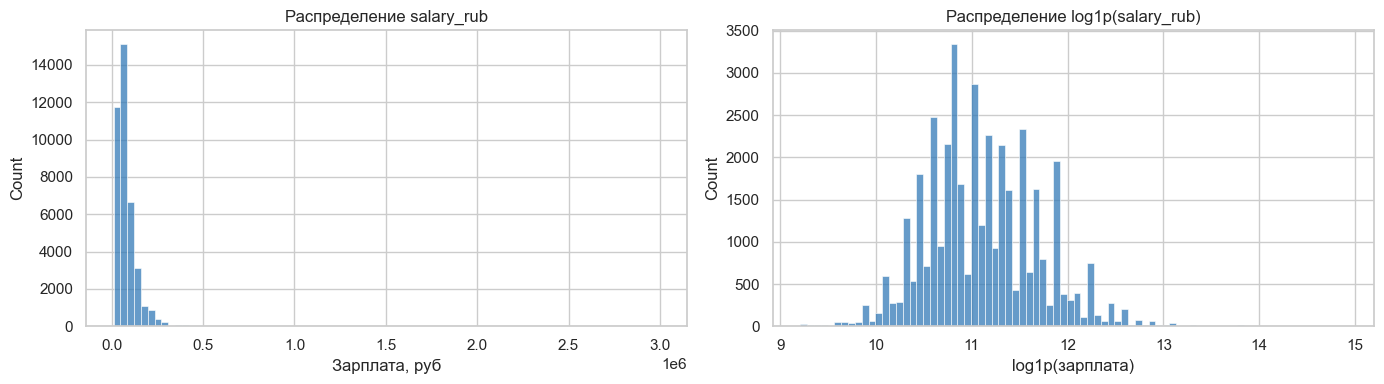

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df[TARGET], bins=80, ax=axes[0], color="#337ab7")
axes[0].set_title("Распределение salary_rub")
axes[0].set_xlabel("Зарплата, руб")

sns.histplot(np.log1p(df[TARGET]), bins=80, ax=axes[1], color="#337ab7")
axes[1].set_title("Распределение log1p(salary_rub)")
axes[1].set_xlabel("log1p(зарплата)")

plt.tight_layout()
plt.savefig(REPORT_IMG / "target_distribution.png", dpi=120)
plt.show()

In [12]:
print(df[TARGET].mean(), df[TARGET].median())

79994.86198338735 60000.0


Распределение `salary_rub` сильно скошено вправо. После `log1p` оно становится ближе к нормальному, что подтверждает целесообразность обучения модели на log1p(salary_rub) с возвратом в рубли через expm1 для метрик

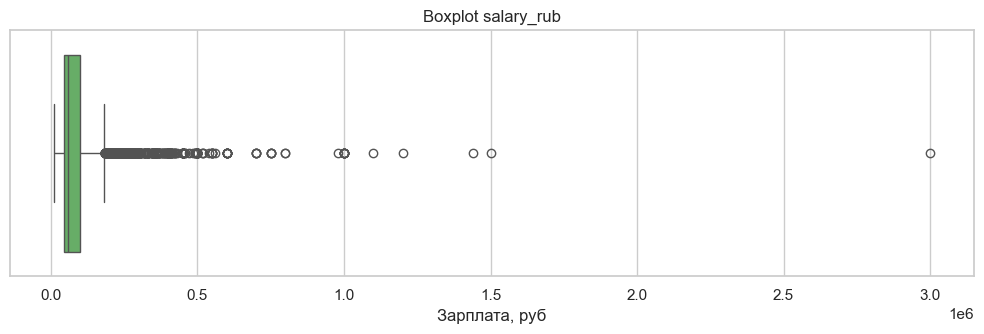

In [17]:
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.boxplot(x=df[TARGET], ax=ax, color="#5cb85c")
ax.set_title("Boxplot salary_rub")
ax.set_xlabel("Зарплата, руб")
plt.tight_layout()
plt.show()

## 4. Группировка колонок и leakage check

Перед визуализациями зафиксируем смысловые группы колонок ... это пригодится при построении пайплайна

In [24]:
id_cols = [c for c in ["id", "link", "data_source"] if c in df.columns]
leak_cols = [c for c in ["salary", "salary_from", "salary_to", "has_salary_from", "has_salary_to"] if c in df.columns]
const_cols = [
    c for c in df.columns
    if df[c].dropna().astype(str).nunique() <= 1
]
id_like_num_cols = [
    c for c in df.columns
    if c.endswith("_id") and c != "id" and pd.api.types.is_numeric_dtype(df[c])
]

text_cols = [c for c in ["name", "description"] if c in df.columns]
list_cols = [c for c in ["languages_parsed", "skills"] if c in df.columns]
datetime_cols = [c for c in ["last_found_at", "year", "month"] if c in df.columns]
bool_cols = [
    c for c in df.select_dtypes(include="bool").columns
    if c not in leak_cols and c not in const_cols
]

num_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in leak_cols + datetime_cols + id_like_num_cols + [TARGET]
]

cat_cols = [
    c for c in df.columns
    if c not in id_cols + leak_cols + const_cols + text_cols + list_cols
    + datetime_cols + bool_cols + num_cols + [TARGET]
]

print("id_cols", id_cols)
print("leak_cols", leak_cols)
print("const_cols", const_cols)
print("text_cols", text_cols)
print("list_cols", list_cols)
print("datetime_cols", datetime_cols)
print("bool_cols", bool_cols)
print("num_cols", num_cols)
print("cat_cols", cat_cols)

id_cols ['id', 'link', 'data_source']
leak_cols ['salary', 'salary_from', 'salary_to', 'has_salary_from', 'has_salary_to']
const_cols ['data_source', 'last_found_at', 'is_open', 'accomodation', 'country_id', 'country_name', 'year', 'month']
text_cols ['name', 'description']
list_cols ['languages_parsed', 'skills']
datetime_cols ['last_found_at', 'year', 'month']
bool_cols ['accept_kids', 'accept_handicapped', 'has_test', 'is_premium']
num_cols ['description_length', 'skills_count', 'languages_count']
cat_cols ['experience', 'employer_id', 'employer_name', 'employer_type', 'employer_industry_id', 'employer_industry_name', 'schedule', 'employment', 'region_id', 'region_name', 'region_district_id', 'region_district_name', 'role_id', 'role_name']


`salary`, `salary_from`, `salary_to`, `has_salary_from`, `has_salary_to` — это исходные поля, из которых построен таргет `salary_rub`. Использовать их как признаки нельзя: модель просто запомнит ответ. На уровне baseline и экспериментов будем явно отбрасывать `leak_cols`

## 5. Анализ числовых признаков

In [25]:
num_for_corr = [c for c in num_cols if df[c].nunique(dropna=True) > 1]
corr = (
    df[num_for_corr + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)
corr.to_frame("corr_with_target").head(20)

,corr_with_target
description_length,0.144092
skills_count,0.111261
languages_count,0.053198


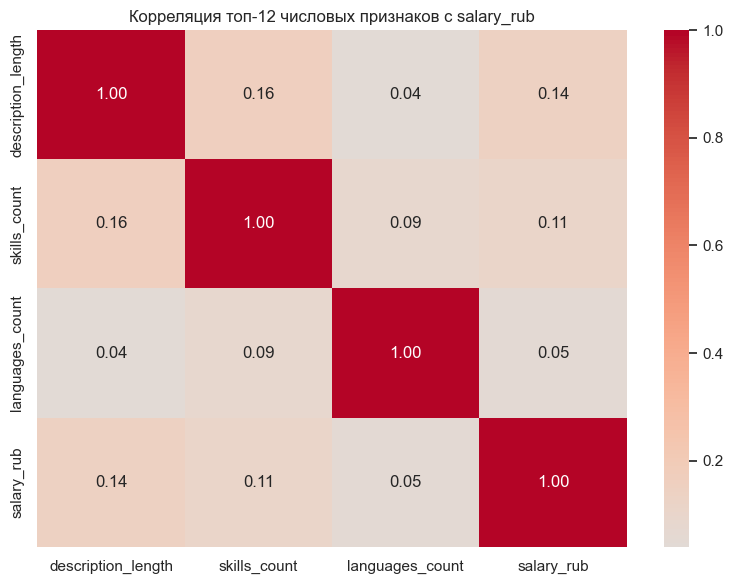

In [26]:
top_num = corr.head(12).index.tolist()
if top_num:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(df[top_num + [TARGET]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
    ax.set_title("Корреляция топ-12 числовых признаков с salary_rub")
    plt.tight_layout()
    plt.savefig(REPORT_IMG / "corr_heatmap.png", dpi=120)
    plt.show()

/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


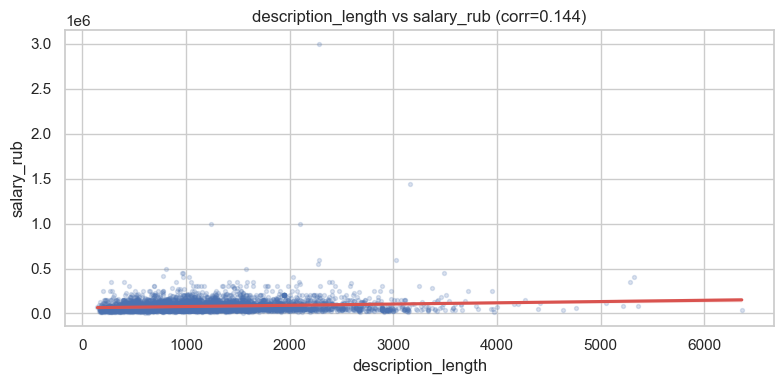

/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


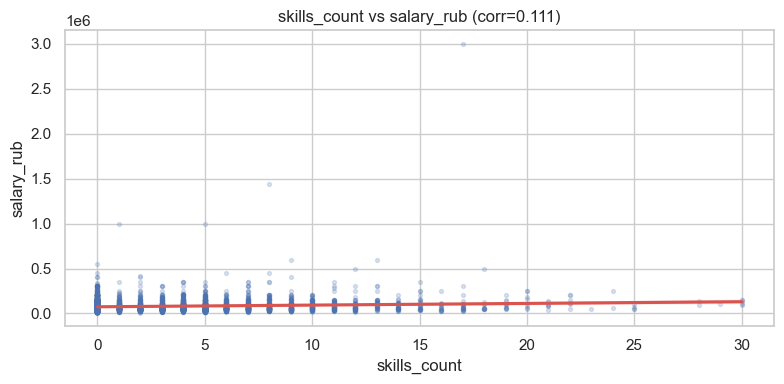

/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


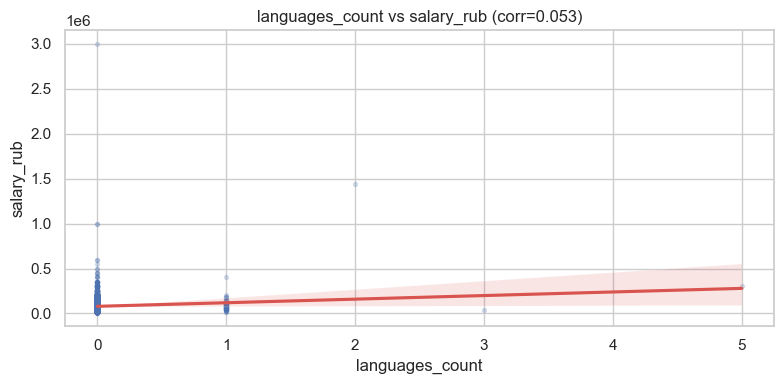

In [27]:
for c in corr.head(3).index:
    sample = df[[c, TARGET]].sample(min(5000, len(df)), random_state=SEED)
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.regplot(
        data=sample, x=c, y=TARGET,
        scatter_kws={"alpha": 0.2, "s": 8},
        line_kws={"color": "#d9534f"}, ax=ax,
    )
    ax.set_title(f"{c} vs {TARGET} (corr={corr[c]:.3f})")
    plt.tight_layout()
    plt.show()

## 6. Анализ категориальных признаков

In [28]:
cat_summary = []
for c in cat_cols:
    s = df[c].astype("string")
    if s.dropna().empty:
        continue
    top = s.mode(dropna=True).iloc[0]
    cat_summary.append({
        "feature": c,
        "n_unique": s.nunique(dropna=True),
        "top": top,
        "top_share": s.value_counts(normalize=True, dropna=True).iloc[0],
    })
pd.DataFrame(cat_summary).sort_values("n_unique")

,feature,n_unique,top,top_share
3,employer_type,3,company,0.911632
0,experience,4,1-3,0.440539
7,employment,4,full,0.930662
6,schedule,5,full_day,0.636421
5,employer_industry_name,8,Юриспруденция,0.293947
10,region_district_id,8,1,0.338989
11,region_district_name,8,Центральный,0.338989
4,employer_industry_id,9,0,0.825542
8,region_id,87,347,0.148096
9,region_name,87,Москва,0.148096


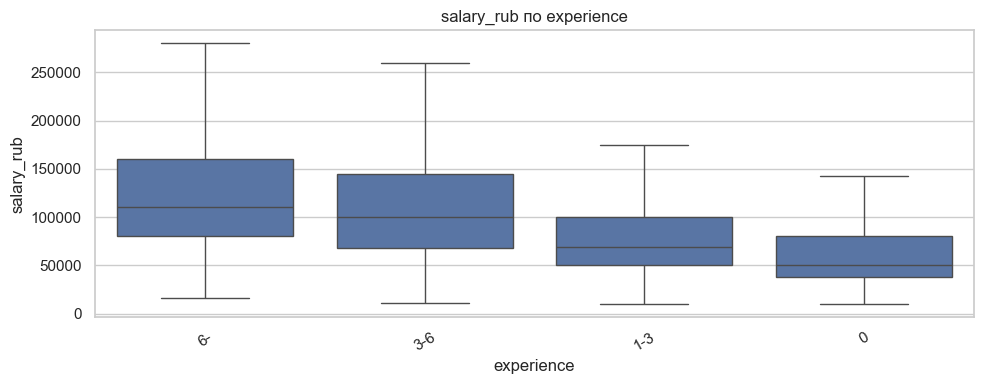

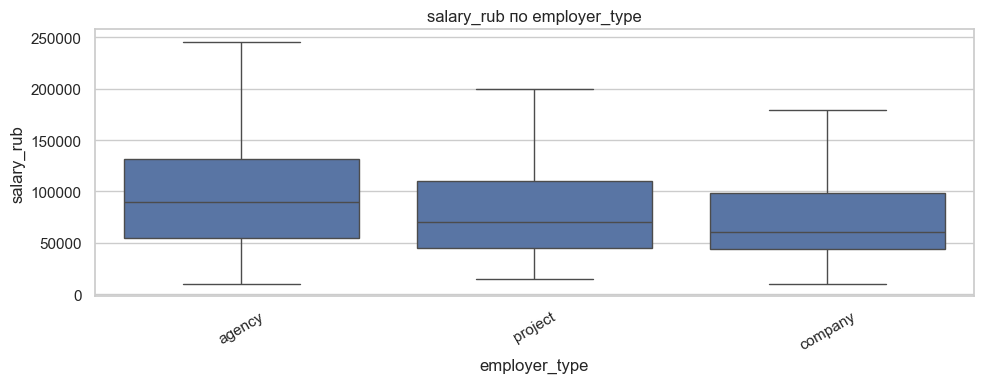

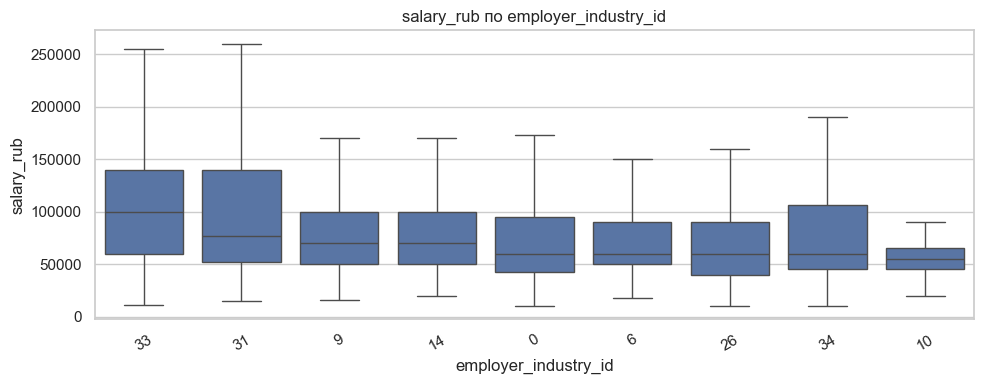

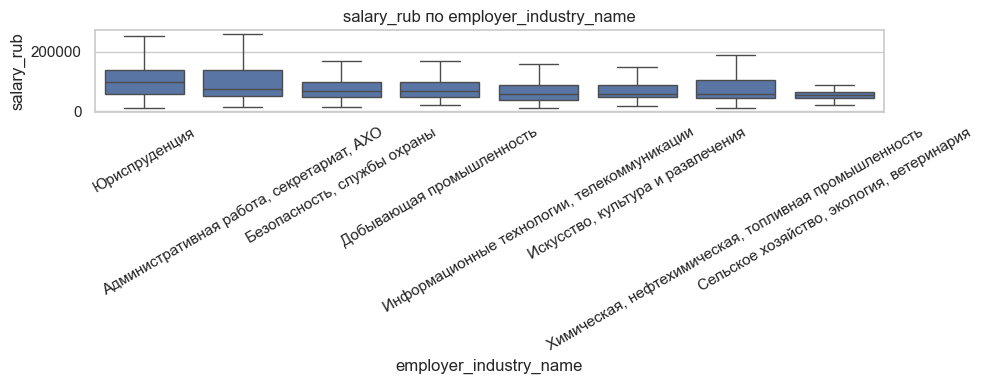

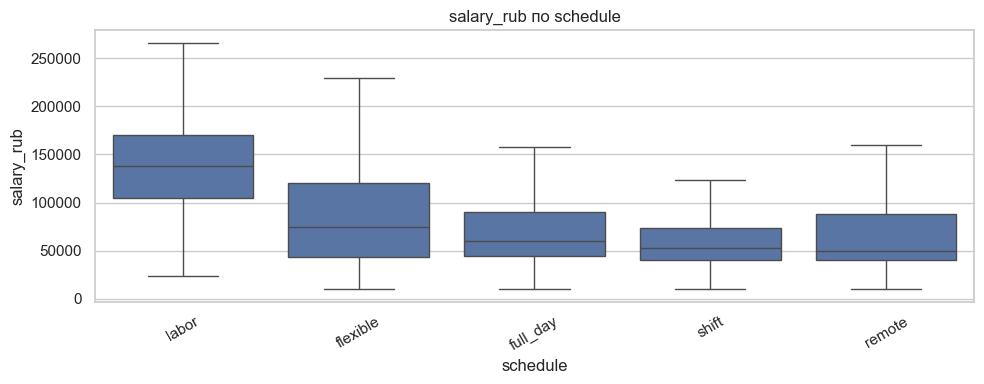

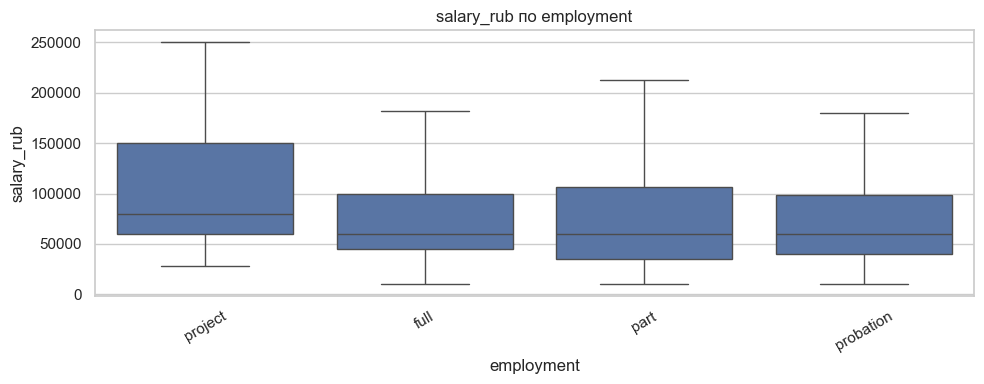

In [29]:
small_cat = [c for c in cat_cols if 1 < df[c].nunique(dropna=True) <= 30]
for c in small_cat[:6]:
    order = df.groupby(c)[TARGET].median().sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(data=df, x=c, y=TARGET, order=order, ax=ax, showfliers=False)
    ax.set_title(f"salary_rub по {c}")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()

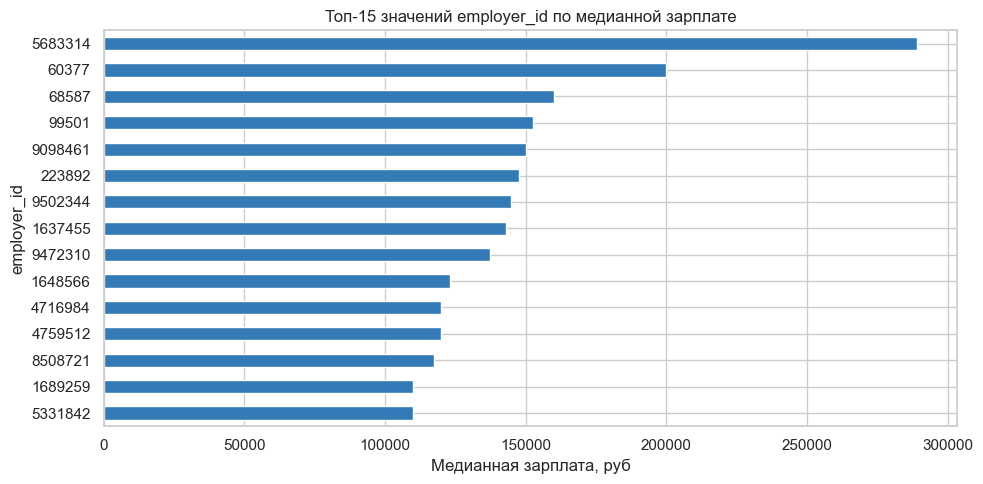

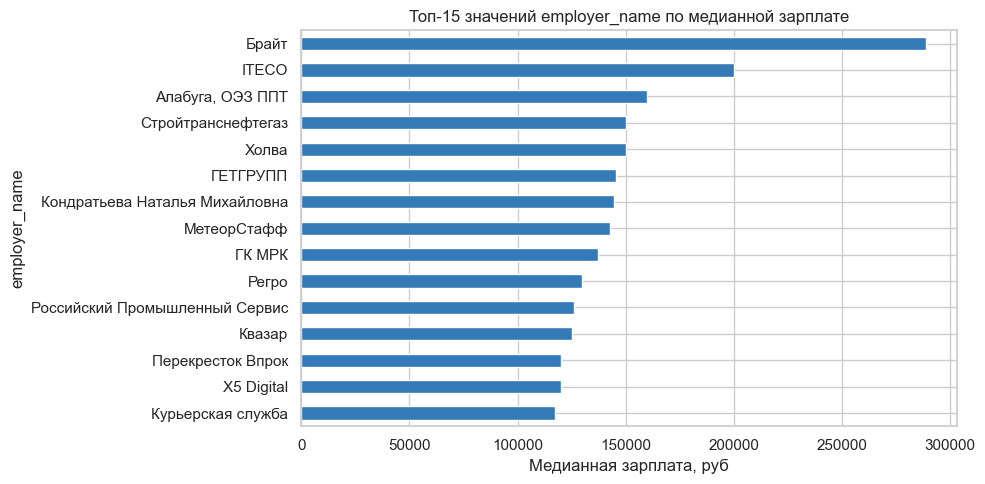

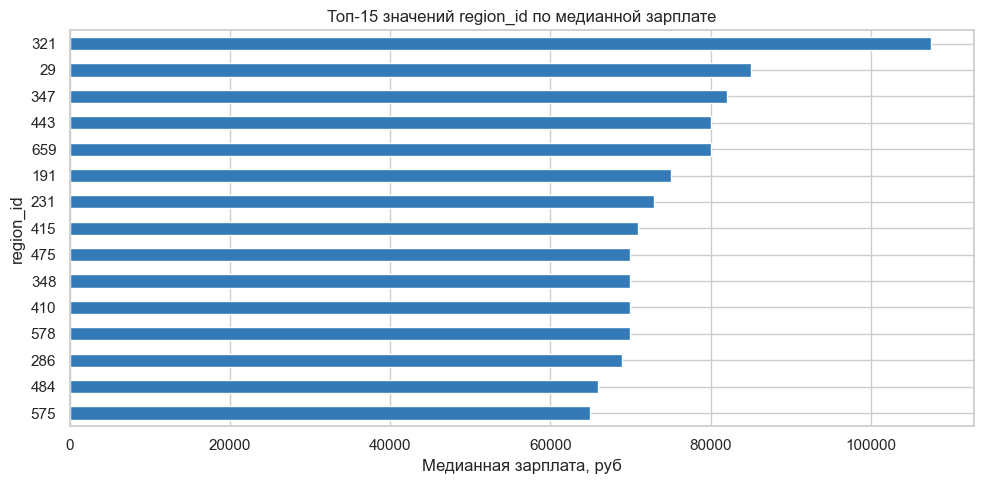

In [30]:
high_card = [c for c in cat_cols if df[c].nunique(dropna=True) > 30]
for c in high_card[:3]:
    top = (
        df.groupby(c)[TARGET]
        .agg(["median", "count"])
        .query("count >= 30")
        .sort_values("median", ascending=False)
        .head(15)
    )
    if top.empty:
        continue
    fig, ax = plt.subplots(figsize=(10, 5))
    top["median"].plot.barh(ax=ax, color="#337ab7")
    ax.set_title(f"Топ-15 значений {c} по медианной зарплате")
    ax.set_xlabel("Медианная зарплата, руб")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 7. Анализ булевых признаков

In [31]:
bool_for_analysis = [c for c in bool_cols if c not in leak_cols and df[c].nunique() == 2]
if bool_for_analysis:
    rows = []
    for c in bool_for_analysis:
        grp = df.groupby(c)[TARGET].agg(["median", "mean", "count"])
        rows.append({
            "feature": c,
            "median_False": grp.loc[False, "median"] if False in grp.index else np.nan,
            "median_True": grp.loc[True, "median"]  if True  in grp.index else np.nan,
            "count_True": int(df[c].sum()),
            "count_False": int((~df[c]).sum()),
        })
    bool_effect = pd.DataFrame(rows)
    bool_effect["diff"] = bool_effect["median_True"] - bool_effect["median_False"]
    bool_effect = bool_effect.sort_values("diff", key=abs, ascending=False)
else:
    bool_effect = pd.DataFrame()
bool_effect

,feature,median_False,median_True,count_True,count_False,diff
0,accept_kids,60000.0,126000.0,174,39314,66000.0
3,is_premium,60000.0,95000.0,807,38681,35000.0
2,has_test,60000.0,70000.0,192,39296,10000.0
1,accept_handicapped,60000.0,60000.0,1502,37986,0.0


## 8. Анализ списочных признаков (`skills`, `languages_parsed`)

Топ-20 навыков по частоте:
skills
Работа в команде                       4604
Грамотная речь                         3444
Пользователь ПК                        2989
Активные продажи                       2187
Деловое общение                        1898
Навыки продаж                          1779
Телефонные переговоры                  1670
Умение работать в команде              1438
Деловая переписка                      1250
Организаторские навыки                 1124
Работа с большим объемом информации    1074
Поиск и привлечение клиентов           1025
Обучение и развитие                    1006
Заключение договоров                    901
Ведение переговоров                     881
Деловая коммуникация                    865
Прямые продажи                          844
Ответственность                         813
Точность и внимательность к деталям     773
Умение работать в коллективе            764
Name: count, dtype: int64


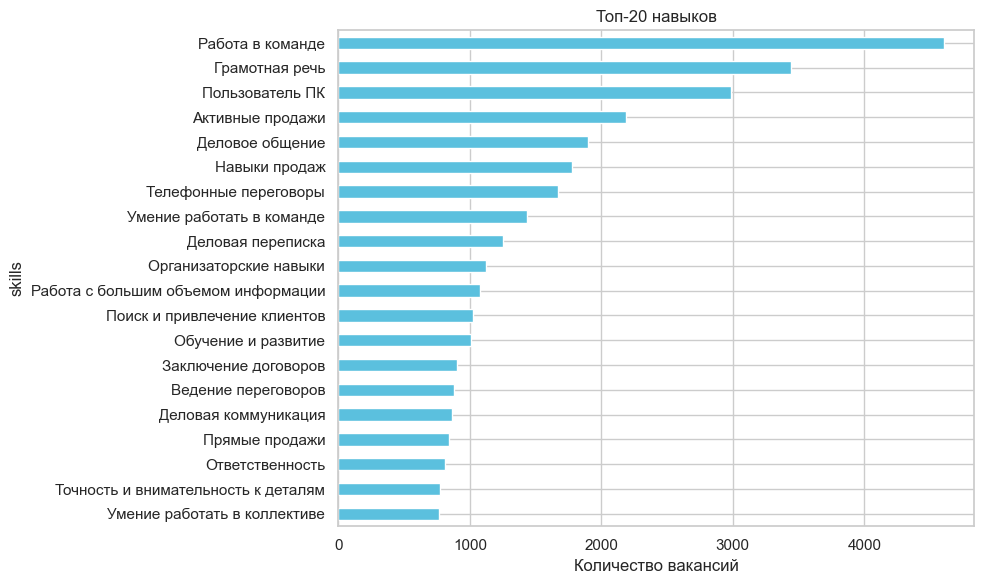

In [32]:
if "skills" in df.columns:
    all_skills = df["skills"].explode()
    top_skills = all_skills.value_counts().head(20)
    print("Топ-20 навыков по частоте:")
    print(top_skills)

    fig, ax = plt.subplots(figsize=(10, 6))
    top_skills.iloc[::-1].plot.barh(ax=ax, color="#5bc0de")
    ax.set_title("Топ-20 навыков")
    ax.set_xlabel("Количество вакансий")
    plt.tight_layout()
    plt.savefig(REPORT_IMG / "top_skills.png", dpi=120)
    plt.show()

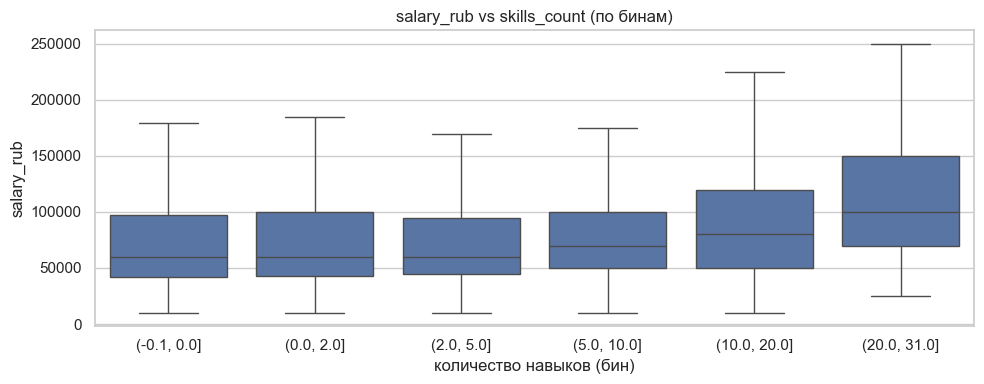

In [34]:
if "skills_count" in df.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    bins = pd.cut(df["skills_count"], bins=[-0.1, 0, 2, 5, 10, 20, df["skills_count"].max() + 1])
    sns.boxplot(x=bins, y=df[TARGET], ax=ax, showfliers=False)
    ax.set_title("salary_rub vs skills_count (по бинам)")
    ax.set_xlabel("количество навыков (бин)")
    plt.tight_layout()
    plt.show()

## 9. Временной срез

In [37]:
print("Уникальных дат last_found_at", df["last_found_at"].nunique())
print("Min/max", df["last_found_at"].min(), "—", df["last_found_at"].max())
print("Уникальных year", df["year"].unique())
print("Уникальных month", df["month"].unique())
print(df["last_found_at"].value_counts().head())

Уникальных дат last_found_at 1
Min/max 2023-11-01 00:00:00 — 2023-11-01 00:00:00
Уникальных year [2023]
Уникальных month [11]
last_found_at
2023-11-01    39488
Name: count, dtype: int64


Все данные после фильтрации оказались за ноябрь 23 года, так что смысла от этой фичи нет

In [38]:
# Колонки, которые не несут сигнала удаляем
cols_to_drop = sorted(set(leak_cols + const_cols))
print(f"Удаляем {len(cols_to_drop)} колонок:")
for c in cols_to_drop:
    reason = []
    if c in leak_cols:
        reason.append("утечка таргета")
    if c in const_cols:
        reason.append("константа")
    print(f"  - {c}  ({', '.join(reason)})")

df = df.drop(columns=cols_to_drop)
print(f"\nОсталось колонок: {df.shape[1]}")
print(f"Размер датасета:  {df.shape[0]:,} × {df.shape[1]}")

Удаляем 13 колонок:
  - accomodation  (константа)
  - country_id  (константа)
  - country_name  (константа)
  - data_source  (константа)
  - has_salary_from  (утечка таргета)
  - has_salary_to  (утечка таргета)
  - is_open  (константа)
  - last_found_at  (константа)
  - month  (константа)
  - salary  (утечка таргета)
  - salary_from  (утечка таргета)
  - salary_to  (утечка таргета)
  - year  (константа)

Осталось колонок: 28
Размер датасета:  39,488 × 28


In [39]:
# Пересобираем группы после удаления
id_cols       = [c for c in id_cols       if c in df.columns]
text_cols     = [c for c in text_cols     if c in df.columns]
list_cols     = [c for c in list_cols     if c in df.columns]
datetime_cols = [c for c in datetime_cols if c in df.columns]
bool_cols     = [c for c in bool_cols     if c in df.columns]
num_cols      = [c for c in num_cols      if c in df.columns]
cat_cols      = [c for c in cat_cols      if c in df.columns]

print("После очистки:")
print("id_cols", id_cols)
print("text_cols", text_cols)
print("list_cols", list_cols)
print("datetime_cols", datetime_cols)
print("bool_cols", bool_cols)
print("num_cols", num_cols)
print("cat_cols", cat_cols)

После очистки:
id_cols ['id', 'link']
text_cols ['name', 'description']
list_cols ['languages_parsed', 'skills']
datetime_cols []
bool_cols ['accept_kids', 'accept_handicapped', 'has_test', 'is_premium']
num_cols ['description_length', 'skills_count', 'languages_count']
cat_cols ['experience', 'employer_id', 'employer_name', 'employer_type', 'employer_industry_id', 'employer_industry_name', 'schedule', 'employment', 'region_id', 'region_name', 'region_district_id', 'region_district_name', 'role_id', 'role_name']


Теперь с данными можно работать дальше

## 10. Train / Val / Test split
вот так я буду делить данные для обучения в 02_baseline

In [41]:
from sklearn.model_selection import train_test_split
salary_bins = pd.qcut(np.log1p(df[TARGET]), q=10, labels=False, duplicates="drop")

train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=salary_bins,
)
temp_bins = salary_bins.loc[temp_df.index]
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_bins,
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"train {len(train_df):>7,}  ({len(train_df) / len(df):.1%})")
print(f"val {len(val_df):>7,}  ({len(val_df) / len(df):.1%})")
print(f"test {len(test_df):>7,}  ({len(test_df) / len(df):.1%})")

train  27,641  (70.0%)
val   5,923  (15.0%)
test   5,924  (15.0%)


/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-projec

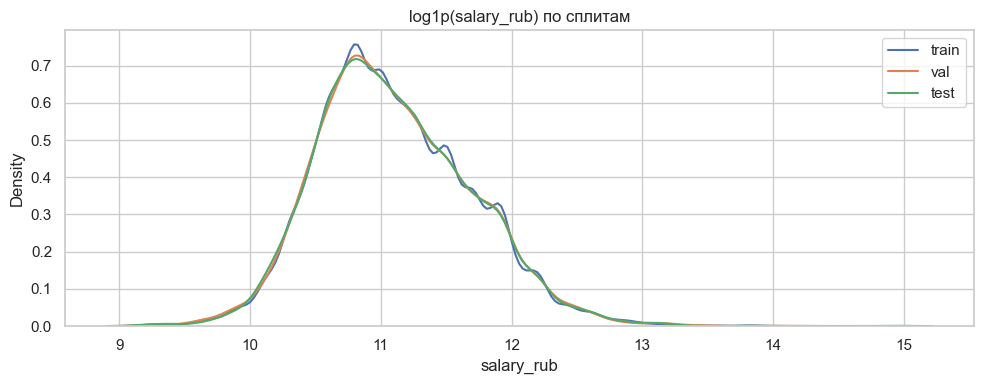

In [42]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, sub in [("train", train_df), ("val", val_df), ("test", test_df)]:
    sns.kdeplot(np.log1p(sub[TARGET]), label=name, ax=ax)
ax.set_title("log1p(salary_rub) по сплитам")
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_IMG / "split_distribution.png", dpi=120)
plt.show()

In [43]:
df.to_parquet(DATA_PROCESSED / "vacancies_clean.parquet", index=False)
print(f"{DATA_PROCESSED / 'vacancies_clean.parquet'}")

/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/data/processed/vacancies_clean.parquet


## 11. Метрика качества и обоснование

Задача — регрессия на сильно скошенном таргете

| Метрика | Плюсы | Минусы |
|---|---|---|
| **MAE** | Интуитивна, устойчива к выбросам, легко объяснять | Не штрафует крупные ошибки сильнее |
| **RMSE** | Сильнее наказывает крупные промахи | Чувствительна к выбросам |
| **MAPE** | Относительная ошибка, шкало-независимая | Взрывается на маленьких зарплатах |
| **R²** | Хорошо для сравнения моделей | Не интерпретируема в рублях |
| **MedAE** | Медианная абсолютная ошибка, ещё устойчивее | Не реагирует на хвосты |

Основная метрика — MAE в рублях. Потому что зарплата абсолютная величина и важно «на сколько рублей в среднем модель ошибается». Распределение скошено, есть тяжёлые хвосты и MAE легко интерпретировать
Получается такая раскладка:
MAE ... главное число для бизнеса и для финального вывода о качестве
RMSE ... диагностика поведения на высоких зарплатах + стандарт
R2 ... удобный безразмерный показатель для сравнения моделей